# Asset pre-selection

Not every asset in a universe earns its place. Some carry no information at all — a constant
column, a name that never traded. Some are dominated: you asked for the twenty lowest-risk
names and got two hundred. And some are redundant, moving so closely with another asset that
keeping both tells the optimiser the same thing twice, inflating its confidence in a
correlation structure that is really one factor wearing two hats.

**Asset selectors** narrow the universe from the data, as ordinary preprocessing estimators.
They know nothing about pipelines; a `Pipeline` drives them through
`fit_preprocessing` and `apply_preprocessing` exactly as it drives a prior
estimator through `prior`. Three families:

  - `CompleteAssetSelector` — drop any asset column holding a `missing` or `NaN`.
  - `ScoreSelector` — score every asset with a risk measure, keep what a rule admits.
    `ZeroVarianceFilter` is the named special case.
  - `RedundancySelector` — discard assets that duplicate information others carry.

The idea that makes all of this safe is that **the universe a selector chooses on the
training window is its fitted state**. Applying the fitted result to an unseen window
*replays* that universe rather than re-deciding it. Without that, selection would be the
purest form of look-ahead bias: choosing your assets using the returns you are about to be
scored on.

> **When to reach for this**
>
> Reach for a selector whenever the universe itself is a modelling decision rather than a
> given. Degenerate columns (`ZeroVarianceFilter`, `CompleteAssetSelector`) are hygiene —
> run them always. Score-based selection (`ScoreSelector`) is a *hypothesis*: that
> pre-screening on a risk measure improves out-of-sample outcomes. Redundancy pruning
> (`RedundancySelector`) is a *conditioning* fix, for when a near-singular correlation
> matrix is destabilising the optimiser. Screening and pruning are hyperparameters — tune
> them inside cross-validation (§7), never on the full sample.

In [1]:
using PortfolioOptimisers, PrettyTables, DataFrames, Statistics, StatsAPI

resfmt = (v, i, j) -> begin
    if isa(v, Number) && !isa(v, Integer)
        return "$(round(v * 100, digits = 3)) %"
    else
        return v
    end
end;

## 1. The data

Twenty S&P 500 names, the last 1000 trading days. Real data, so the correlations are real
too — that matters for §5, where two algorithms that sound equivalent give different answers.

In [2]:
using CSV, TimeSeries

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)
rd = prices_to_returns(X[(end - 1000):end])
size(rd.X), rd.nx

((1000, 20), ["AAPL", "AMD", "BAC", "BBY", "CVX", "GE", "HD", "JNJ", "JPM", "KO", "LLY", "MRK", "MSFT", "PEP", "PFE", "PG", "RRC", "UNH", "WMT", "XOM"])

## 2. Scoring an asset with a risk measure

`ScoreSelector` scores asset `i` by evaluating a risk measure on **that asset's own return
series**: `score(view(X, :, i))`. There is no separate score taxonomy to learn, because the
risk-measure family already spans everything you would want to rank on — variance and
semi-variance, VaR and CVaR, the drawdown measures, and `MeanReturn`.

Two traits do the work. `supports_precomputed_returns` says whether a measure's
functor can consume a bare return series at all, and `bigger_is_better` says which end
of the resulting ordering is "best".

In [3]:
measures = ["SCM()" => SCM(), "ConditionalValueatRisk()" => ConditionalValueatRisk(),
            "MaximumDrawdown()" => MaximumDrawdown(), "MeanReturn()" => MeanReturn(),
            "Variance()" => Variance()]

pretty_table(DataFrame(; measure = first.(measures),
                       scoreable = [PortfolioOptimisers.supports_precomputed_returns(r)
                                    for (_, r) in measures],
                       bigger_is_better = [PortfolioOptimisers.bigger_is_better(r)
                                           for (_, r) in measures]))

┌──────────────────────────┬───────────┬──────────────────┐
│                  measure │ scoreable │ bigger_is_better │
│                   String │      Bool │             Bool │
├──────────────────────────┼───────────┼──────────────────┤
│                    SCM() │      true │            false │
│ ConditionalValueatRisk() │      true │            false │
│        MaximumDrawdown() │      true │            false │
│             MeanReturn() │      true │             true │
│               Variance() │     false │            false │
└──────────────────────────┴───────────┴──────────────────┘


So `ConditionalValueatRisk` is minimised and `MeanReturn` is maximised, and a rule that says
`best` means the right thing for each without you having to remember which.

In [4]:
cvar = PortfolioOptimisers.asset_scores(ConditionalValueatRisk(), rd.X)
mu = PortfolioOptimisers.asset_scores(MeanReturn(), rd.X)
pretty_table(sort(DataFrame(; asset = rd.nx, cvar = cvar, mean_return = mu), :cvar);
             formatters = [resfmt])

┌────────┬─────────┬─────────────┐
│  asset │    cvar │ mean_return │
│ String │ Float64 │     Float64 │
├────────┼─────────┼─────────────┤
│    JNJ │ 3.045 % │      0.05 % │
│    WMT │  3.25 % │     0.058 % │
│    PEP │ 3.276 % │     0.074 % │
│     PG │  3.38 % │     0.072 % │
│    MRK │ 3.562 % │     0.067 % │
│     KO │ 3.615 % │     0.054 % │
│    PFE │ 3.807 % │     0.051 % │
│    LLY │ 3.881 % │      0.14 % │
│    UNH │ 4.288 % │     0.103 % │
│   MSFT │ 4.509 % │     0.105 % │
│     HD │  4.51 % │     0.084 % │
│    JPM │  4.67 % │     0.062 % │
│   AAPL │ 4.785 % │     0.146 % │
│    XOM │ 5.122 % │     0.089 % │
│    BAC │ 5.236 % │     0.061 % │
│      ⋮ │       ⋮ │           ⋮ │
└────────┴─────────┴─────────────┘
                    5 rows omitted


### 2.1 `Variance` cannot score a single asset

This is the one sharp edge in reusing the risk-measure family, and it is worth meeting
head-on. `Variance` is a `WeightsInput` measure: its functor consumes
portfolio *weights* and a covariance matrix, not a return series. It has no meaning applied to
one asset in isolation, so `ScoreSelector` rejects it at construction rather than silently
computing something else.

In [5]:
try
    ScoreSelector(; score = Variance(), rule = ThresholdRule(; lo = 0.0))
catch e
    println(e.msg)
end

`Variance` cannot score a single asset's return series: its `supports_precomputed_returns` is false, so its functor consumes portfolio weights rather than a precomputed return vector. `SCM()` computes the same quantity from a return series and is scoreable.


The remedy is in the error: `SCM()` — the second central moment, an alias for
`LowOrderMoment` with `SecondMoment` and `FullMoment` — computes the
same quantity from a return series, and is scoreable.

In [6]:
PortfolioOptimisers.asset_scores(SCM(), rd.X)[1:3],
var(rd.X[:, 1:3]; dims = 1, corrected = false)

([0.0004644201994021763, 0.0011897682783638284, 0.0005658656139818306], [0.00046395577920277413 0.0011885785100854648 0.0005652997483678488])

## 3. Rules: what to do with the scores

A selection rule turns per-asset scores into
a keep-mask. Rules come in two kinds, and the distinction is not cosmetic.

**Literal.** `ThresholdRule` compares raw scores against absolute bounds `(lo, hi)`,
both optional and both exclusive. It **ignores** `bigger_is_better`. That is deliberate: a
zero-variance filter must drop the *low*-variance assets, so a trait-aware "keep the better
ones" would invert its whole purpose.

**Ordinal.** `RankRule` and `QuantileRule` sort the assets best-to-worst,
consulting `bigger_is_better`, and take **counts (or fractions) from each end**. Not
positions — counts. That is what makes "drop the worst 5" expressible without knowing how many
assets there are, and what lets you take both tails at once.

In [7]:
rules = ["RankRule(best = 5)" => RankRule(; best = 5),
         "RankRule(worst = 5)" => RankRule(; worst = 5),
         "RankRule(worst = 3, action = :drop)" => RankRule(; worst = 3, action = :drop),
         "RankRule(best = 2, worst = 2)" => RankRule(; best = 2, worst = 2),
         "QuantileRule(best = 0.25)" => QuantileRule(; best = 0.25)]

rows = map(rules) do (label, rule)
    kept = fit_preprocessing(ScoreSelector(; score = ConditionalValueatRisk(), rule = rule),
                             rd).nx
    return (; rule = label, n = length(kept), kept = join(kept, ", "))
end
pretty_table(DataFrame(rows))

┌─────────────────────────────────────┬───────┬─────────────────────────────────
│                                rule │     n │                                ⋯
│                              String │ Int64 │                                ⋯
├─────────────────────────────────────┼───────┼─────────────────────────────────
│                  RankRule(best = 5) │     5 │                                ⋯
│                 RankRule(worst = 5) │     5 │                                ⋯
│ RankRule(worst = 3, action = :drop) │    17 │ AAPL, BAC, BBY, CVX, HD, JNJ,  ⋯
│       RankRule(best = 2, worst = 2) │     4 │                                ⋯
│           QuantileRule(best = 0.25) │     5 │                                ⋯
└─────────────────────────────────────┴───────┴─────────────────────────────────
                                                                1 column omitted


Note the orientation flip. `ConditionalValueatRisk` is minimised, so `best = 5` returns the
five *defensive* names. Swap the score for `MeanReturn`, which is maximised, and `best = 5`
returns the five *growth* names — the same rule, the opposite end of the table, and no flag to
remember.

In [8]:
DataFrame(; rule = ["best = 5", "worst = 5"],
          by_cvar = [join(fit_preprocessing(ScoreSelector(;
                                                          score = ConditionalValueatRisk(),
                                                          rule = RankRule(; best = 5)), rd).nx,
                          ", "),
                     join(fit_preprocessing(ScoreSelector(;
                                                          score = ConditionalValueatRisk(),
                                                          rule = RankRule(; worst = 5)),
                                            rd).nx, ", ")],
          by_mean_return = [join(fit_preprocessing(ScoreSelector(; score = MeanReturn(),
                                                                 rule = RankRule(;
                                                                                 best = 5)),
                                                   rd).nx, ", "),
                            join(fit_preprocessing(ScoreSelector(; score = MeanReturn(),
                                                                 rule = RankRule(;
                                                                                 worst = 5)),
                                                   rd).nx, ", ")])

Row,rule,by_cvar,by_mean_return
,String,String,String
1,best = 5,"JNJ, MRK, PEP, PG, WMT","AAPL, AMD, LLY, MSFT, RRC"
2,worst = 5,"AMD, BBY, CVX, GE, RRC","BAC, JNJ, KO, PFE, WMT"


### 3.1 Hygiene: degenerate columns

`ZeroVarianceFilter` is `ScoreSelector(; score = SCM(), rule = ThresholdRule(; lo = tol))`
under a friendlier name. A constant column has zero variance, contributes nothing, and makes a
covariance matrix singular.

`CompleteAssetSelector` is its counterpart for missingness at the returns level —
useful when a pipeline is fed a `ReturnsResult` directly and the price-level
`MissingDataFilter` never runs.

In [9]:
Xz = copy(rd.X)
Xz[:, 4] .= 0.0                                  # BBY stops trading
rd_z = ReturnsResult(; nx = rd.nx, X = Xz)
setdiff(rd.nx, fit_preprocessing(ZeroVarianceFilter(), rd_z).nx)

1-element Vector{String}:
 "BBY"

`tol` defaults to `1e-12` rather than `0` because a column that moves by 1e-18 is constant for
every purpose that matters, and the bound is exclusive so `tol = 0` still drops an exactly
constant asset.

## 4. Ties: if we cannot tell them apart, keep neither

This is the library's one genuinely surprising rule, so it is worth understanding rather than
discovering.

When two assets are **indistinguishable under the criterion being applied**, neither is kept.
A tied block straddling a rank cut is dropped whole rather than split arbitrarily. The
alternative — breaking the tie by column index — would make your portfolio depend on the order
of the columns in your CSV, which is not a property of the data.

The consequence to internalise: **`RankRule(; best = k)` may return fewer than `k` assets.**

In [10]:
v = PortfolioOptimisers.asset_scores(SCM(), rd.X)
ord = sortperm(v)                                # ascending variance; lower is better
Xs = copy(rd.X)
Xs[:, ord[3]] = Xs[:, ord[2]]                    # make ranks 2 and 3 tie exactly
rd_tie = ReturnsResult(; nx = rd.nx, X = Xs)

tie_rows = map([1, 2, 3]) do k
    kept = fit_preprocessing(ScoreSelector(; score = SCM(), rule = RankRule(; best = k)),
                             rd_tie).nx
    return (; requested = k, returned = length(kept), kept = join(kept, ", "))
end
pretty_table(DataFrame(tie_rows))

┌───────────┬──────────┬─────────────┐
│ requested │ returned │        kept │
│     Int64 │    Int64 │      String │
├───────────┼──────────┼─────────────┤
│         1 │        1 │         JNJ │
│         2 │        1 │         JNJ │
│         3 │        3 │ JNJ, KO, PG │
└───────────┴──────────┴─────────────┘


`best = 2` returns one asset: ranks 2 and 3 tie, the block straddles the cut, so it is
excluded. `best = 3` returns three: the same block now fits entirely inside the cut, so it is
kept whole. And a window whose scores are *all* equal selects nothing — which
`fit_preprocessing` reports as an error rather than handing an empty universe
downstream.

The same stance governs redundancy. Two identical columns are perfectly correlated and score
identically, so neither survives.

In [11]:
rd_dup = ReturnsResult(; nx = [rd.nx; "AAPL_copy"], X = hcat(rd.X, rd.X[:, 1]))
dup_kept = fit_preprocessing(RedundancySelector(; alg = PairwiseCorrelation(; t = 0.99),
                                                score = SCM()), rd_dup).nx
("AAPL" in dup_kept, "AAPL_copy" in dup_kept, length(dup_kept))

(false, false, 19)

## 5. Redundancy: two algorithms, two different answers

`RedundancySelector` has two parts. `alg` decides *which* assets are redundant;
`score` decides *which member of a redundant group survives*. Leave `score` as `nothing` and
the correlation algorithms fall back on their own rule — the asset with the lowest summary
correlation to the rest of the universe survives, i.e. the least redundant one.

The two correlation algorithms sound interchangeable. They are not.

`PairwiseCorrelation` is **greedy**. It visits correlated pairs from most to least
correlated and drops the worse asset of each, until no surviving pair exceeds `t`. That is
the literal promise the threshold makes, and it is the default.

`CorrelationComponents` reads the same correlations **transitively**. Assets are nodes,
over-threshold correlations are edges, and each connected component keeps one representative.
If `ρ(A,B) = 0.97` and `ρ(B,C) = 0.97` but `ρ(A,C) = 0.10`, all three are one component and two
are discarded — even though `A` and `C` are uncorrelated.

Chaining is not hypothetical. On real data, at the same threshold:

In [12]:
greedy = RedundancySelector(; alg = PairwiseCorrelation(; t = 0.65, absolute = true),
                            score = SCM())
comps = RedundancySelector(; alg = CorrelationComponents(; t = 0.65, absolute = true),
                           score = SCM())

kept_g = fit_preprocessing(greedy, rd).nx
kept_c = fit_preprocessing(comps, rd).nx

# the greedy guarantee, verified: no surviving pair exceeds t
gi = [findfirst(==(n), rd.nx) for n in kept_g]
sub = abs.(cor(rd.X[:, gi]))
max_surviving = maximum(sub[i, j] for j in axes(sub, 2) for i in (j + 1):size(sub, 1))

DataFrame(; algorithm = ["PairwiseCorrelation", "CorrelationComponents"],
          kept = [length(kept_g), length(kept_c)],
          max_surviving_abs_cor = [round(max_surviving; digits = 3), missing],
          extra_drops = ["—", join(setdiff(kept_g, kept_c), ", ")])

Row,algorithm,kept,max_surviving_abs_cor,extra_drops
,String,Int64,Float64?,String
1,PairwiseCorrelation,15,0.643,—
2,CorrelationComponents,13,missing,"KO, XOM"


`absolute = true` treats a correlation of `-0.9` as redundant too, which is usually what you
want: two assets moving in lockstep carry the same information whichever sign it comes with.

Neither answer is wrong. Greedy honours the promise a threshold makes and keeps more assets;
components makes the stronger claim that a correlated blob deserves one representative, and
reduces harder. Choose knowingly.

### 5.1 Clustering as the grouping rule

`ClusterGroups` partitions with `clusterise`, so the entire clustering family —
hierarchical linkage, DBHT, the optimal-number-of-clusters estimators — becomes a way to define
"redundant". It has no fallback survivor rule, so it *requires* a `score`.

In [13]:
clustered = RedundancySelector(; alg = ClusterGroups(), score = SCM())
kept_cl = fit_preprocessing(clustered, rd).nx
length(kept_cl), join(kept_cl, ", ")

try
    RedundancySelector(; alg = ClusterGroups())            # no score
catch e
    println(e.msg)
end

a ClusterGroups redundancy algorithm cannot choose the survivor of a group on its own; give the RedundancySelector a score


## 6. The universe is fitted state

Everything above ran `fit_preprocessing` on one window. In a pipeline, that window is the
*training* window, and the selected universe is carried in the fitted result. Predicting on an
unseen window **replays** it.

In [14]:
selector = ScoreSelector(; score = ConditionalValueatRisk(), rule = RankRule(; best = 10))
train = ReturnsResult(; nx = rd.nx, X = rd.X[1:700, :])
test = ReturnsResult(; nx = rd.nx, X = rd.X[701:end, :])

fitted = fit_preprocessing(selector, train)
replayed = apply_preprocessing(fitted, test)

# the *test* window's own ten lowest-CVaR names would have been different
would_have_chosen = fit_preprocessing(selector, test).nx

DataFrame(; universe = ["fitted on train", "replayed on test", "test window's own choice"],
          assets = [join(fitted.nx, ", "), join(replayed.nx, ", "),
                    join(would_have_chosen, ", ")])

Row,universe,assets
,String,String
1,fitted on train,"HD, JNJ, KO, LLY, MRK, MSFT, PEP, PFE, PG, WMT"
2,replayed on test,"HD, JNJ, KO, LLY, MRK, MSFT, PEP, PFE, PG, WMT"
3,test window's own choice,"JNJ, JPM, KO, LLY, MRK, PEP, PFE, PG, UNH, WMT"


The replayed universe is the training one, not the test window's own. That difference is the
look-ahead bias a fit/apply contract exists to prevent.

### 6.1 Step order is checked, not assumed

A selector shrinks `:returns`. Any slot already derived from `:returns` — a prior, a phylogeny,
an uncertainty set, generated constraints — is then computed on an asset universe that no
longer exists. `Pipeline` rejects that ordering at construction rather than letting a stale,
asset-misdimensioned prior reach the optimiser.

In [15]:
try
    Pipeline(; steps = (EmpiricalPrior(), ZeroVarianceFilter(), EqualWeighted()))
catch e
    println(e.msg)
end

a ScoreSelector step writes the :returns slot, invalidating the :prior slot written by an earlier EmpiricalPrior step; the stale :prior result would no longer match the assets of the new :returns data. Move the ScoreSelector step before the EmpiricalPrior step, or drop one of them.


Put the selector first, and it composes with everything else without comment.

In [16]:
using Clarabel
slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

pipe = Pipeline(;
                steps = ("select" => ScoreSelector(; score = ConditionalValueatRisk(),
                                                   rule = RankRule(; best = 10)),
                         EmpiricalPrior(),
                         "opt" => MeanRisk(; opt = JuMPOptimiser(; slv = slv))))
res = StatsAPI.fit(pipe, rd)
pretty_table(DataFrame(; asset = res.ctx.returns.nx, weight = res.w); formatters = [resfmt])

┌────────┬──────────┐
│  asset │   weight │
│ String │  Float64 │
├────────┼──────────┤
│    JNJ │ 25.982 % │
│     KO │ 17.616 % │
│    LLY │    0.0 % │
│    MRK │ 17.463 % │
│   MSFT │    0.0 % │
│    PEP │    0.0 % │
│    PFE │  6.215 % │
│     PG │  4.853 % │
│    UNH │    0.0 % │
│    WMT │ 27.871 % │
└────────┴──────────┘


Ten assets in, ten weights out. `predict` on any window replays the fitted ten.

In [17]:
pred = StatsAPI.predict(res, rd)
expected_risk(ConditionalValueatRisk(), pred)

0.02478727525516734

## 7. Selection is a hyperparameter

How many assets should you keep? That is not a question to answer by looking at the answer.
`search_cross_validation` fits the *entire* pipeline — selection included — on each
training window and scores it on the held-out one, so no candidate ever sees the test window
while choosing its universe.

Lens keys reach into the selector by name: `"select.rule"` swaps the whole rule.

In [18]:
p = ["select.rule" => [RankRule(; best = 5), RankRule(; best = 10), RankRule(; best = 15)]]
gscv = GridSearchCrossValidation(p; cv = IndexWalkForward(500, 250),
                                 r = ConditionalValueatRisk())
tuned = search_cross_validation(pipe, gscv, rd)

pretty_table(DataFrame(; k = [v[1].best for v in tuned.val_grid],
                       mean_score = vec(mean(tuned.test_scores; dims = 1))))

┌───────┬────────────┐
│     k │ mean_score │
│ Int64 │    Float64 │
├───────┼────────────┤
│     5 │ -0.0214013 │
│    10 │ -0.0204401 │
│    15 │ -0.0204521 │
└───────┴────────────┘


`tuned.opt` is the winning *pipeline*, selector and all, ready to fit on the full sample.

In [19]:
tuned.opt.steps[1].rule.best

10

Two things make this honest. Counts **saturate** at the number of assets, so a grid point of
`best = 50` on a 20-asset universe keeps 20 rather than throwing — a sweep is never killed by
its largest point. And every *other* degenerate case fails closed: an unscoreable measure, a
rule that selects nothing, a non-finite score, a fitted asset missing from a test window.

## 8. Visualising the two decisions

The score-and-rule decision is one dimension: sort the assets, cut somewhere.

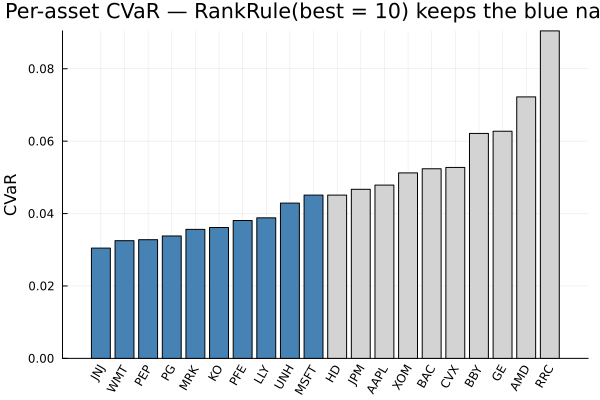

In [20]:
using StatsPlots

perm = sortperm(cvar)
kept10 = fit_preprocessing(ScoreSelector(; score = ConditionalValueatRisk(),
                                         rule = RankRule(; best = 10)), rd).nx
colours = [n in kept10 ? :steelblue : :lightgray for n in rd.nx[perm]]

bar(1:length(perm), cvar[perm]; color = colours, legend = false,
    xticks = (1:length(perm), rd.nx[perm]), xrotation = 60, ylabel = "CVaR",
    title = "Per-asset CVaR — RankRule(best = 10) keeps the blue names")

The redundancy decision is a threshold sweep, and it shows the chaining gap opening up. The two
algorithms agree only once the graph has no chains left to traverse.

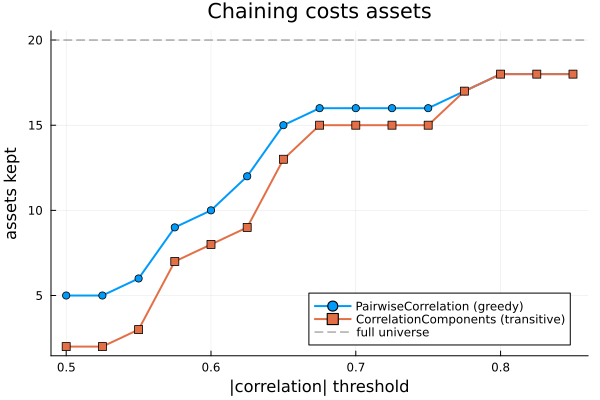

In [21]:
thrs = 0.5:0.025:0.85
n_greedy = [length(fit_preprocessing(RedundancySelector(;
                                                        alg = PairwiseCorrelation(; t = t,
                                                                                  absolute = true),
                                                        score = SCM()), rd).nx)
            for t in thrs]
n_comps = [length(fit_preprocessing(RedundancySelector(;
                                                       alg = CorrelationComponents(; t = t,
                                                                                   absolute = true),
                                                       score = SCM()), rd).nx)
           for t in thrs]

plot(thrs, n_greedy; label = "PairwiseCorrelation (greedy)", marker = :circle, lw = 2)
plot!(thrs, n_comps; label = "CorrelationComponents (transitive)", marker = :square, lw = 2)
hline!([length(rd.nx)]; label = "full universe", ls = :dash, color = :gray)
plot!(; xlabel = "|correlation| threshold", ylabel = "assets kept",
      title = "Chaining costs assets", legend = :bottomright)

## Summary

  - Asset selectors are returns-level preprocessing estimators. The universe chosen on the
    training window is **fitted state**, replayed on unseen windows — that is what keeps
    selection out of the look-ahead-bias family.
  - `ScoreSelector` scores each asset with any risk measure whose
    `supports_precomputed_returns` is `true`, and `bigger_is_better` orients
    `best`/`worst` so you never pass a direction flag. `Variance` is not scoreable;
    use `SCM()`.
  - `ThresholdRule` is literal and ignores orientation; `RankRule` and
    `QuantileRule` are ordinal and take counts (or fractions) **from each end**, so
    "drop the worst 5" needs no knowledge of `n`.
  - Ties are excluded, never split. `RankRule(; best = k)` may return fewer than `k` assets,
    and two identical columns leave no survivor.
  - `PairwiseCorrelation` guarantees no surviving pair exceeds the threshold;
    `CorrelationComponents` reads correlation transitively and reduces harder. They
    give different answers on the same input, by design.
  - A step that rewrites `:returns` after a prior, phylogeny, uncertainty, or constraint step
    is rejected at construction — the stale-universe bug is unrepresentable.
  - Selection thresholds and counts are hyperparameters. Tune them with
    `search_cross_validation`, never on the full sample.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*